In [ ]:
!pip install h5py

#1. CSI average 圖

data_D1 raw shape from h5py: (2048, 45)
data_D1 fixed shape: (45, 2048)
data_D2 raw shape from h5py: (2048, 45)
data_D2 fixed shape: (45, 2048)
data_D3 raw shape from h5py: (2048, 45)
data_D3 fixed shape: (45, 2048)
data_D4 raw shape from h5py: (2048, 45)
data_D4 fixed shape: (45, 2048)
data_D5 raw shape from h5py: (2048, 45)
data_D5 fixed shape: (45, 2048)
data_D6 raw shape from h5py: (2048, 45)
data_D6 fixed shape: (45, 2048)


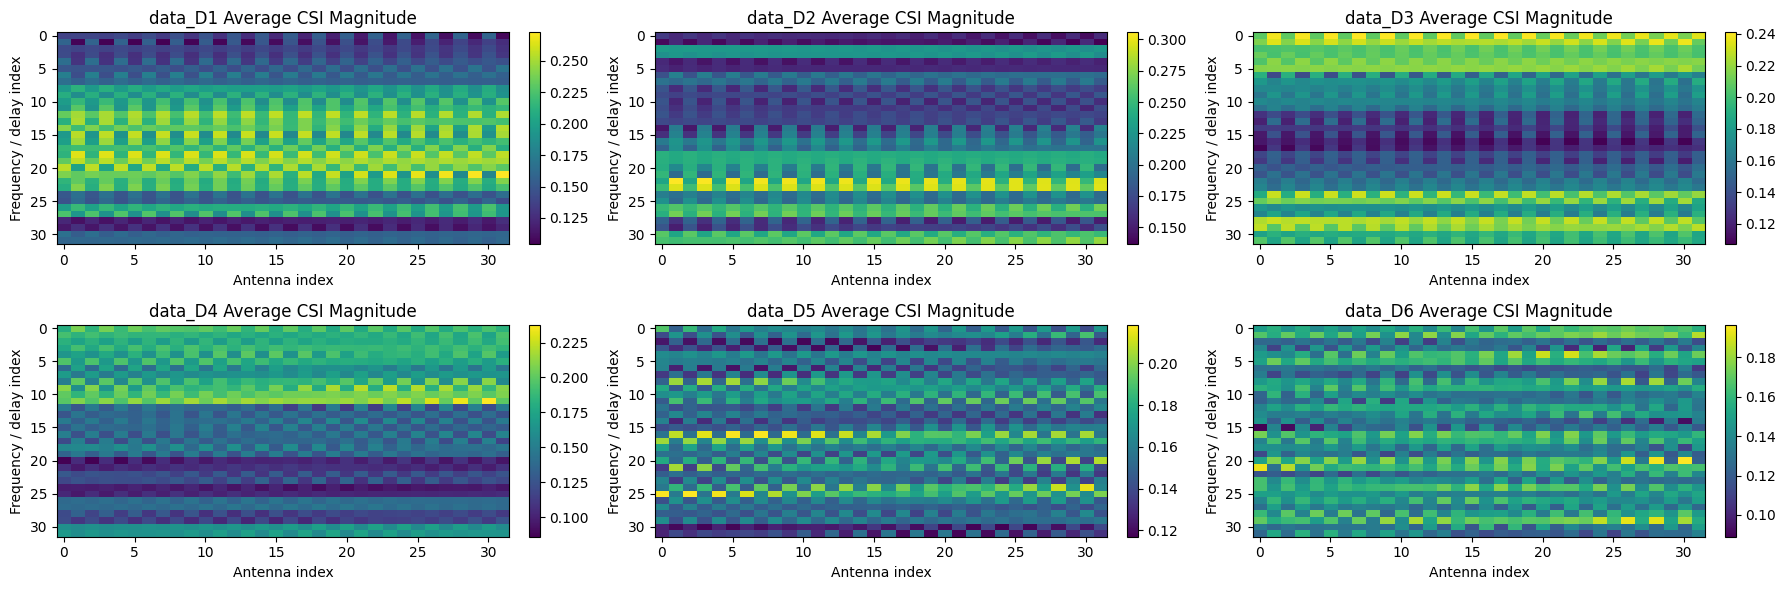

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/matdata"
DATASETS = ["data_D1", "data_D2", "data_D3", "data_D4", "data_D5", "data_D6"]

def load_v73_mat_var(path, var_name):
    """Read MATLAB v7.3 .mat variable using h5py."""
    with h5py.File(path, "r") as f:
        data = np.array(f[var_name])
    return data

plt.figure(figsize=(18, 6))

for i, ds in enumerate(DATASETS):
    path = os.path.join(BASE, ds, "DATA_Htestin.mat")

    HT = load_v73_mat_var(path, "HT")
    print(ds, "raw shape from h5py:", HT.shape)

    # MATLAB 存 N x 2048，但 h5py 讀出來常會變成 2048 x N
    if HT.shape[0] == 2048:
        HT = HT.T

    print(ds, "fixed shape:", HT.shape)

    # N x 2048 -> N x 2 x 32 x 32
    X = HT.reshape(-1, 2, 32, 32)

    real = X[:, 0] - 0.5
    imag = X[:, 1] - 0.5
    mag = np.sqrt(real**2 + imag**2)

    avg_mag = np.mean(mag, axis=0)

    ax = plt.subplot(2, 3, i + 1)
    im = ax.imshow(avg_mag, aspect="auto")
    ax.set_title(f"{ds} Average CSI Magnitude")
    ax.set_xlabel("Antenna index")
    ax.set_ylabel("Frequency / delay index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("CSI_average_D1_to_D6.png", dpi=300)
plt.show()

#2. Frequency Response Signals圖

H_transfer compound fields: dict_keys(['real', 'imag'])
D1_raw.mat loaded shape: (128, 9, 257, 50) dtype: complex128
D1_raw.mat fixed shape: (50, 257, 9, 128)
H_transfer compound fields: dict_keys(['real', 'imag'])
D2_raw.mat loaded shape: (128, 9, 257, 50) dtype: complex128
D2_raw.mat fixed shape: (50, 257, 9, 128)
H_transfer compound fields: dict_keys(['real', 'imag'])
D3_raw.mat loaded shape: (128, 9, 257, 50) dtype: complex128
D3_raw.mat fixed shape: (50, 257, 9, 128)
H_transfer compound fields: dict_keys(['real', 'imag'])
D4_raw.mat loaded shape: (128, 9, 257, 50) dtype: complex128
D4_raw.mat fixed shape: (50, 257, 9, 128)
H_transfer compound fields: dict_keys(['real', 'imag'])
D5_raw.mat loaded shape: (128, 9, 257, 50) dtype: complex128
D5_raw.mat fixed shape: (50, 257, 9, 128)
H_transfer compound fields: dict_keys(['real', 'imag'])
D6_raw.mat loaded shape: (128, 9, 257, 50) dtype: complex128
D6_raw.mat fixed shape: (50, 257, 9, 128)


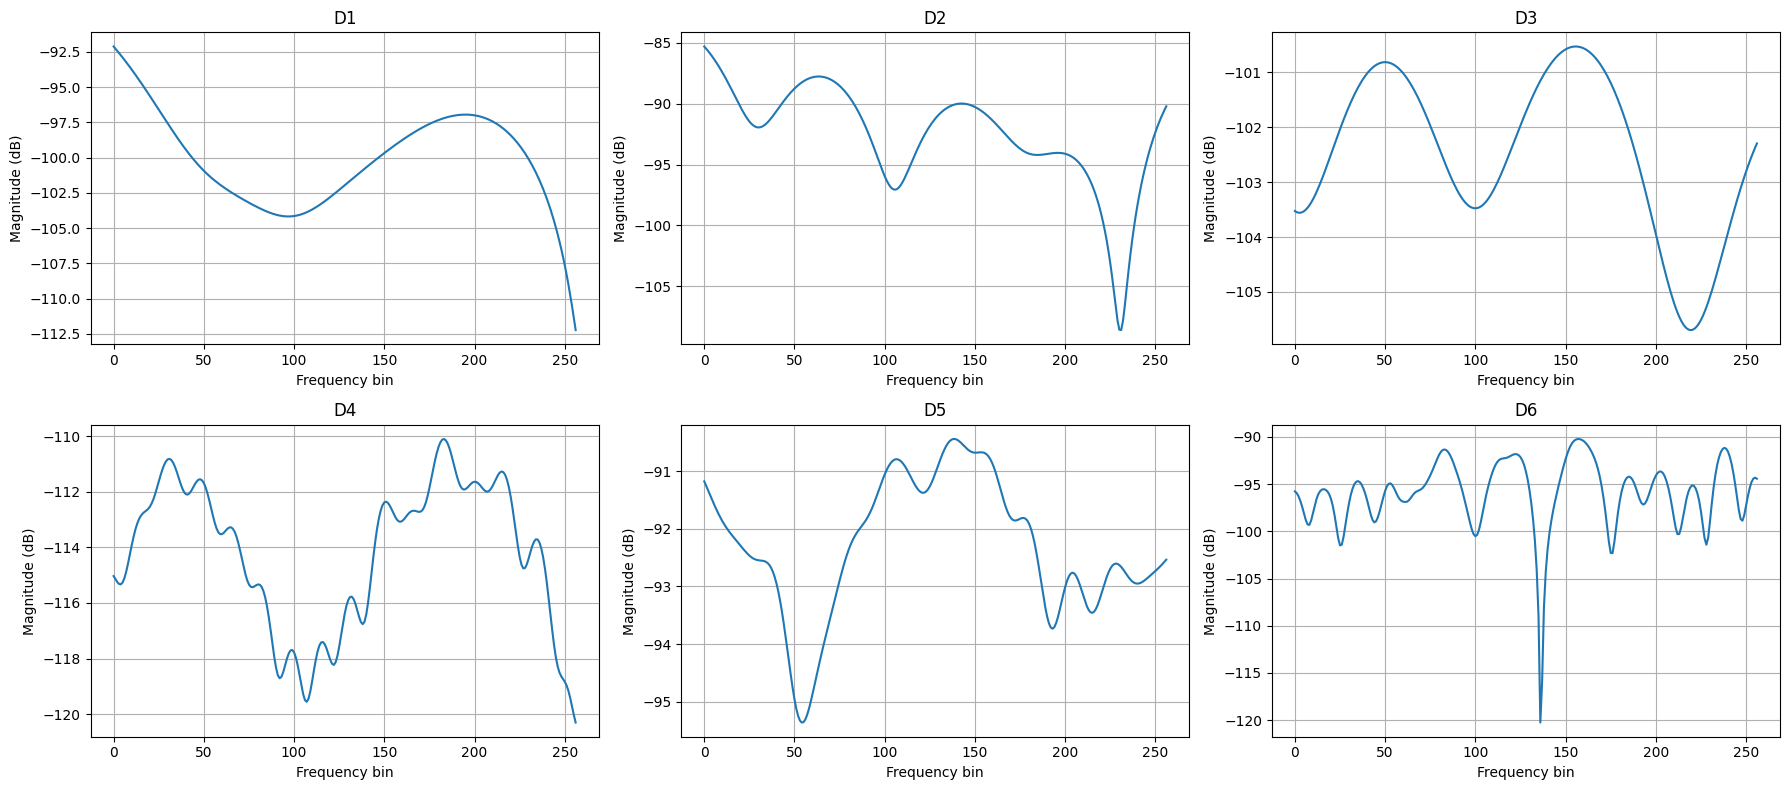

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/matdata"  # 改成你的 raw .mat 所在資料夾
RAW_FILES = ["D1_raw.mat", "D2_raw.mat", "D3_raw.mat", "D4_raw.mat", "D5_raw.mat", "D6_raw.mat"]

def load_mat73_complex(path, key):
    with h5py.File(path, "r") as f:
        dset = f[key]
        arr = np.array(dset)

    # MATLAB v7.3 complex often becomes compound dtype: fields = real / imag
    if arr.dtype.fields is not None:
        fields = arr.dtype.fields.keys()
        print(key, "compound fields:", fields)

        if "real" in fields and "imag" in fields:
            arr = arr["real"] + 1j * arr["imag"]
        elif "r" in fields and "i" in fields:
            arr = arr["r"] + 1j * arr["i"]
        else:
            raise ValueError(f"Unknown complex fields: {fields}")

    return arr

plt.figure(figsize=(18, 8))

for i, raw_file in enumerate(RAW_FILES):
    path = os.path.join(BASE, raw_file)

    if not os.path.exists(path):
        print("Missing:", path)
        continue

    H = load_mat73_complex(path, "H_transfer")
    print(raw_file, "loaded shape:", H.shape, "dtype:", H.dtype)

    # MATLAB: 50 x 257 x 9 x 128
    # h5py usually reads reversed: 128 x 9 x 257 x 50
    if H.shape[0] == 128:
        H = np.transpose(H, (3, 2, 1, 0))

    print(raw_file, "fixed shape:", H.shape)

    snapshot = 0
    user = 0
    antenna = 0

    signal = H[snapshot, :, user, antenna]
    power_db = 20 * np.log10(np.abs(signal) + 1e-12)

    ax = plt.subplot(2, 3, i + 1)
    ax.plot(power_db)
    ax.set_title(raw_file.replace("_raw.mat", ""))
    ax.set_xlabel("Frequency bin")
    ax.set_ylabel("Magnitude (dB)")
    ax.grid(True)

plt.tight_layout()
plt.savefig("D1_to_D6_frequency_response_signals.png", dpi=300)
plt.show()

#3. CsiNet Model Training + Testing

TensorFlow version: 2.19.0
DATA_ROOT: /content/drive/MyDrive/matdata/data_D5
RESULT_ROOT: /content/drive/MyDrive/matdata/result_D5
Raw x_train: (360, 2048)
Raw x_val: (45, 2048)
Raw x_test: (45, 2048)
Raw X_test: (45, 32, 125)
Final x_train: (360, 32, 32, 2)
Final x_val: (45, 32, 32, 2)
Final x_test: (45, 32, 32, 2)
Final X_test: (45, 32, 125)


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 32, 32, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 32, 32, 2) │         38 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 2) │          8 │ conv2d_76[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_66      │ (None, 32, 32, 2) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 2048)      │          0 │ leaky_re_lu_66[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense       │ (None, 512)       │  1,049,088 │ flatten_6[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 2048)      │  1,050,624 │ encoder_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 32, 32, 2) │          0 │ dense_10[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 32, 32, 8) │        152 │ reshape_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 8) │         32 │ conv2d_77[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_67      │ (None, 32, 32, 8) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 32, 32,    │      1,168 │ leaky_re_lu_67[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_78[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_68      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 32, 32, 2) │        290 │ leaky_re_lu_68[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 2) │          8 │ conv2d_79[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 32, 32, 2) │          0 │ reshape_10[0][0], │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_69      │ (None, 32, 32, 2) │          0 │ add_20[0][0]      │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,103,224 (8.02 MB)

 Trainable params: 2,103,116 (8.02 MB)

 Non-trainable params: 108 (432.00 B)

Epoch 1/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 401ms/step - loss: 0.0505 - val_loss: 0.0174
Epoch 2/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 260ms/step - loss: 0.0224 - val_loss: 0.0174
Epoch 3/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - loss: 0.0200 - val_loss: 0.0172
Epoch 4/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step - loss: 0.0177 - val_loss: 0.0172
Epoch 5/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - loss: 0.0164 - val_loss: 0.0171
Epoch 6/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - loss: 0.0155 - val_loss: 0.0170
Epoch 7/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - loss: 0.0148 - val_loss: 0.0169
Epoch 8/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - loss: 0.0141 - val_loss: 0.0168
Epoch 9/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step - loss: 0.0135 - val_loss: 0.0167
Epoch 10/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - loss: 0.0130 - val_loss: 0.0166
Epoch 11/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - loss: 0.0125 - val_loss: 0.0165
Epoch 12/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/ste

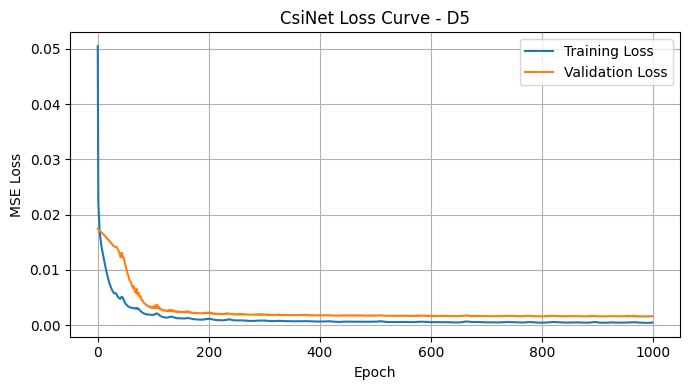

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Average inference time per sample: 0.00678011 sec
Dataset: D5
Encoded dimension: 512
NMSE: -10.217243 dB
Correlation: 0.159410


/tmp/ipykernel_957/2849285149.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  n1 = np.sqrt(np.sum(np.conj(X_test) * X_test, axis=1)).astype("float64")
/tmp/ipykernel_957/2849285149.py:293: ComplexWarning: Casting complex values to real discards the imaginary part
  n2 = np.sqrt(np.sum(np.conj(X_hat) * X_hat, axis=1)).astype("float64")


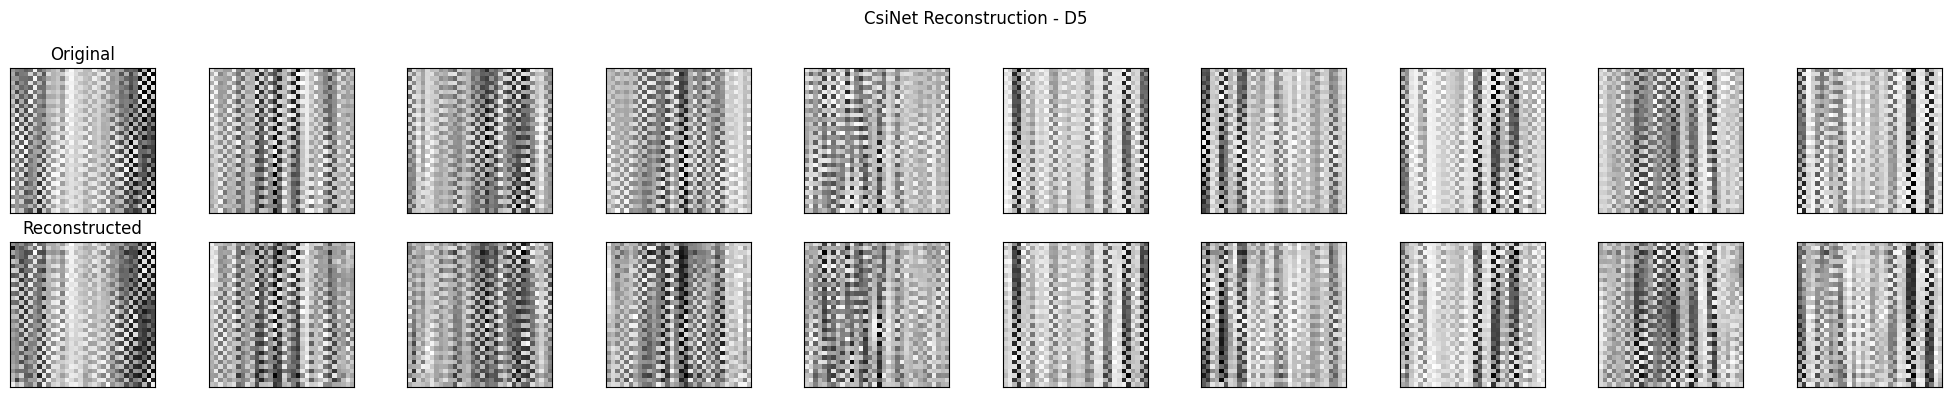

Saved files:
Loss curve: /content/drive/MyDrive/matdata/result_D5/loss_curve_CsiNet_D5_dim512_04_26_1421.png
Reconstruction figure: /content/drive/MyDrive/matdata/result_D5/reconstruction_CsiNet_D5_dim512_04_26_1421.png
Metrics: /content/drive/MyDrive/matdata/result_D5/metrics_CsiNet_D5_dim512_04_26_1421.txt
Model JSON: /content/drive/MyDrive/matdata/result_D5/model_CsiNet_D5_dim512_04_26_1421.json
Weights: /content/drive/MyDrive/matdata/result_D5/model_CsiNet_D5_dim512_04_26_1421.weights.h5


In [ ]:
import os
import time
import math
import h5py
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Reshape, Conv2D, Add, LeakyReLU, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard, Callback
from tensorflow.keras import backend as K

print("TensorFlow version:", tf.__version__)

# =========================================================
# 1. Basic Settings
# =========================================================
BASE_DIR = "/content/drive/MyDrive/matdata"

# 改這裡即可：D1, D2, D3, D4, D5, D6
DATASET_ID = "D5"

DATA_ROOT = os.path.join(BASE_DIR, f"data_{DATASET_ID}")
RESULT_ROOT = os.path.join(BASE_DIR, f"result_{DATASET_ID}")

os.makedirs(RESULT_ROOT, exist_ok=True)

img_height = 32
img_width = 32
img_channels = 2
img_total = img_height * img_width * img_channels

residual_num = 2
encoded_dim = 512

EPOCHS = 1000          # 先跑 50；確認可跑後可改 100 / 200 / 1000
BATCH_SIZE = 64     # 你的資料目前每組不大，64 比較穩
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("DATA_ROOT:", DATA_ROOT)
print("RESULT_ROOT:", RESULT_ROOT)

# =========================================================
# 2. Robust MAT Loader: supports v7 and v7.3
# =========================================================
def load_mat_variable(path, key):
    """
    Load MATLAB .mat variable.
    Supports normal MAT files by scipy.io.loadmat and v7.3 HDF5 MAT files by h5py.
    """
    try:
        mat = sio.loadmat(path)
        data = mat[key]
        return data
    except NotImplementedError:
        with h5py.File(path, "r") as f:
            data = np.array(f[key])

        # h5py reads MATLAB arrays with reversed dimension order.
        # HT: MATLAB N x 2048 -> h5py 2048 x N, so transpose it.
        if key == "HT":
            if data.shape[0] == img_total:
                data = data.T

        # HF_all: MATLAB N x 32 x 125 -> h5py 125 x 32 x N, so transpose it.
        if key == "HF_all":
            if len(data.shape) == 3:
                # common h5py shape: 125 x 32 x N
                if data.shape[0] == 125 and data.shape[1] == 32:
                    data = np.transpose(data, (2, 1, 0))

            # handle complex compound dtype if needed
            if data.dtype.fields is not None:
                fields = data.dtype.fields.keys()
                if "real" in fields and "imag" in fields:
                    data = data["real"] + 1j * data["imag"]
                elif "r" in fields and "i" in fields:
                    data = data["r"] + 1j * data["i"]
                else:
                    raise ValueError(f"Unknown complex fields in {key}: {fields}")

        return data

# =========================================================
# 3. Data Loading
# =========================================================
train_path = os.path.join(DATA_ROOT, "DATA_Htrainin.mat")
val_path   = os.path.join(DATA_ROOT, "DATA_Hvalin.mat")
test_path  = os.path.join(DATA_ROOT, "DATA_Htestin.mat")
hf_path    = os.path.join(DATA_ROOT, "DATA_HtestFin_all.mat")

for p in [train_path, val_path, test_path, hf_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")

x_train = load_mat_variable(train_path, "HT")
x_val   = load_mat_variable(val_path, "HT")
x_test  = load_mat_variable(test_path, "HT")
X_test  = load_mat_variable(hf_path, "HF_all")

print("Raw x_train:", x_train.shape)
print("Raw x_val:", x_val.shape)
print("Raw x_test:", x_test.shape)
print("Raw X_test:", X_test.shape)

x_train = x_train.astype("float32")
x_val   = x_val.astype("float32")
x_test  = x_test.astype("float32")

# Original HT shape: N x 2048 = N x (2 x 32 x 32)
# Original CsiNet uses channels_first: N x 2 x 32 x 32
# This Colab version uses channels_last: N x 32 x 32 x 2
x_train = x_train.reshape(-1, 2, 32, 32)
x_val   = x_val.reshape(-1, 2, 32, 32)
x_test  = x_test.reshape(-1, 2, 32, 32)

x_train = np.transpose(x_train, (0, 2, 3, 1))
x_val   = np.transpose(x_val, (0, 2, 3, 1))
x_test  = np.transpose(x_test, (0, 2, 3, 1))

# X_test shape should be N x 32 x 125
X_test = np.asarray(X_test)

print("Final x_train:", x_train.shape)
print("Final x_val:", x_val.shape)
print("Final x_test:", x_test.shape)
print("Final X_test:", X_test.shape)

# =========================================================
# 4. Build CsiNet Autoencoder
# =========================================================
def add_common_layers(y):
    y = BatchNormalization()(y)
    y = LeakyReLU()(y)
    return y

def residual_block_decoded(y):
    shortcut = y

    y = Conv2D(8, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = add_common_layers(y)

    y = Conv2D(16, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = add_common_layers(y)

    y = Conv2D(2, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = BatchNormalization()(y)

    y = Add()([shortcut, y])
    y = LeakyReLU()(y)

    return y

def build_csinet(residual_num=2, encoded_dim=512):
    image_tensor = Input(shape=(img_height, img_width, img_channels))

    x = Conv2D(2, (3, 3), padding="same", data_format="channels_last")(image_tensor)
    x = add_common_layers(x)

    x = Flatten()(x)
    encoded = Dense(encoded_dim, activation="linear", name="encoder_dense")(x)

    x = Dense(img_total, activation="linear")(encoded)
    x = Reshape((img_height, img_width, img_channels))(x)

    for _ in range(residual_num):
        x = residual_block_decoded(x)

    output = Conv2D(
        2,
        (3, 3),
        activation="sigmoid",
        padding="same",
        data_format="channels_last"
    )(x)

    model = Model(inputs=image_tensor, outputs=output)
    return model

autoencoder = build_csinet(residual_num=residual_num, encoded_dim=encoded_dim)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# =========================================================
# 5. Callback
# =========================================================
class LossHistory(Callback):
    def on_train_begin(self, logs=None):
        self.losses_train = []
        self.losses_val = []

    def on_batch_end(self, batch, logs=None):
        self.losses_train.append(logs.get("loss"))

    def on_epoch_end(self, epoch, logs=None):
        self.losses_val.append(logs.get("val_loss"))

history = LossHistory()

file_tag = f"CsiNet_{DATASET_ID}_dim{encoded_dim}" + time.strftime("_%m_%d_%H%M")
tb_path = os.path.join(RESULT_ROOT, f"TensorBoard_{file_tag}")

# =========================================================
# 6. Train
# =========================================================
train_start = time.time()

fit_history = autoencoder.fit(
    x_train,
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val, x_val),
    callbacks=[
        history,
        TensorBoard(log_dir=tb_path)
    ],
    verbose=1
)

train_end = time.time()
print(f"Training time: {(train_end - train_start):.2f} sec")

# Save loss
train_loss_path = os.path.join(RESULT_ROOT, f"trainloss_{file_tag}.csv")
val_loss_path = os.path.join(RESULT_ROOT, f"valloss_{file_tag}.csv")

np.savetxt(train_loss_path, np.array(history.losses_train), delimiter=",")
np.savetxt(val_loss_path, np.array(history.losses_val), delimiter=",")

# Plot loss curve
plt.figure(figsize=(7, 4))
plt.plot(fit_history.history["loss"], label="Training Loss")
plt.plot(fit_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"CsiNet Loss Curve - {DATASET_ID}")
plt.legend()
plt.grid(True)
plt.tight_layout()
loss_fig_path = os.path.join(RESULT_ROOT, f"loss_curve_{file_tag}.png")
plt.savefig(loss_fig_path, dpi=300)
plt.show()

# =========================================================
# 7. Testing / Reconstruction
# =========================================================
t_start = time.time()
x_hat = autoencoder.predict(x_test, batch_size=BATCH_SIZE)
t_end = time.time()

print("Average inference time per sample: %.8f sec" % ((t_end - t_start) / x_test.shape[0]))

# =========================================================
# 8. NMSE and Correlation
# =========================================================
# x_test / x_hat shape: N x 32 x 32 x 2
x_test_real = x_test[:, :, :, 0].reshape(len(x_test), -1)
x_test_imag = x_test[:, :, :, 1].reshape(len(x_test), -1)
x_test_C = x_test_real - 0.5 + 1j * (x_test_imag - 0.5)

x_hat_real = x_hat[:, :, :, 0].reshape(len(x_hat), -1)
x_hat_imag = x_hat[:, :, :, 1].reshape(len(x_hat), -1)
x_hat_C = x_hat_real - 0.5 + 1j * (x_hat_imag - 0.5)

# Reconstruct frequency domain for correlation
x_hat_F = x_hat_C.reshape(len(x_hat_C), img_height, img_width)
X_hat = np.fft.fft(
    np.concatenate(
        (x_hat_F, np.zeros((len(x_hat_C), img_height, 257 - img_width))),
        axis=2
    ),
    axis=2
)
X_hat = X_hat[:, :, 0:125]

# Ensure X_test shape = N x 32 x 125
if X_test.shape[0] != len(x_test):
    print("Warning: X_test first dimension does not match x_test.")
    print("X_test shape:", X_test.shape)
    print("x_test shape:", x_test.shape)

# complex conversion if X_test accidentally loaded as real-only
X_test = np.asarray(X_test)

n1 = np.sqrt(np.sum(np.conj(X_test) * X_test, axis=1)).astype("float64")
n2 = np.sqrt(np.sum(np.conj(X_hat) * X_hat, axis=1)).astype("float64")
aa = np.abs(np.sum(np.conj(X_test) * X_hat, axis=1))

rho = np.mean(aa / (n1 * n2 + 1e-12), axis=1)

X_hat_flat = X_hat.reshape(len(X_hat), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

power = np.sum(np.abs(x_test_C) ** 2, axis=1)
mse = np.sum(np.abs(x_test_C - x_hat_C) ** 2, axis=1)

nmse_linear = np.mean(mse / (power + 1e-12))
nmse_db = 10 * math.log10(nmse_linear)
corr = np.mean(rho)

print("====================================")
print(f"Dataset: {DATASET_ID}")
print(f"Encoded dimension: {encoded_dim}")
print(f"NMSE: {nmse_db:.6f} dB")
print(f"Correlation: {corr:.6f}")
print("====================================")

# Save metrics
metrics_path = os.path.join(RESULT_ROOT, f"metrics_{file_tag}.txt")
with open(metrics_path, "w") as f:
    f.write(f"Dataset: {DATASET_ID}\n")
    f.write(f"Encoded dimension: {encoded_dim}\n")
    f.write(f"Epochs: {EPOCHS}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"NMSE_dB: {nmse_db:.6f}\n")
    f.write(f"Correlation: {corr:.6f}\n")

# Save decoded data and rho
decoded_path = os.path.join(RESULT_ROOT, f"decoded_{file_tag}.csv")
rho_path = os.path.join(RESULT_ROOT, f"rho_{file_tag}.csv")

x_hat_flat = x_hat.reshape(len(x_hat), -1)
np.savetxt(decoded_path, x_hat_flat, delimiter=",")
np.savetxt(rho_path, rho, delimiter=",")

# =========================================================
# 9. Visualization: Original vs Reconstructed CSI
# =========================================================
n = min(10, len(x_test))

plt.figure(figsize=(20, 4))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    x_test_mag = np.abs((x_test[i, :, :, 0] - 0.5) + 1j * (x_test[i, :, :, 1] - 0.5))
    plt.imshow(np.max(x_test_mag) - x_test_mag.T)
    plt.gray()
    ax.set_title("Original" if i == 0 else "")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.invert_yaxis()

    ax = plt.subplot(2, n, i + 1 + n)
    x_hat_mag = np.abs((x_hat[i, :, :, 0] - 0.5) + 1j * (x_hat[i, :, :, 1] - 0.5))
    plt.imshow(np.max(x_hat_mag) - x_hat_mag.T)
    plt.gray()
    ax.set_title("Reconstructed" if i == 0 else "")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.invert_yaxis()

plt.suptitle(f"CsiNet Reconstruction - {DATASET_ID}")
plt.tight_layout()
recon_fig_path = os.path.join(RESULT_ROOT, f"reconstruction_{file_tag}.png")
plt.savefig(recon_fig_path, dpi=300)
plt.show()

# =========================================================
# 10. Save Model
# =========================================================
model_json = autoencoder.to_json()

json_path = os.path.join(RESULT_ROOT, f"model_{file_tag}.json")
weights_path = os.path.join(RESULT_ROOT, f"model_{file_tag}.weights.h5")

with open(json_path, "w") as json_file:
    json_file.write(model_json)

autoencoder.save_weights(weights_path)

print("Saved files:")
print("Loss curve:", loss_fig_path)
print("Reconstruction figure:", recon_fig_path)
print("Metrics:", metrics_path)
print("Model JSON:", json_path)
print("Weights:", weights_path)

#4. CS-CsiNet Model Training + Testing

TensorFlow version: 2.19.0
DATA_ROOT: /content/drive/MyDrive/matdata/data_D5
RESULT_ROOT: /content/drive/MyDrive/matdata/result_CS_D5
x_train_flat: (360, 2048)
x_val_flat: (45, 2048)
x_test_flat: (45, 2048)
X_test: (45, 32, 125)
Loading A from: /content/drive/MyDrive/matdata/data_D5/A512.mat
A shape: (512, 2048)
y_train: (360, 512)
y_val: (45, 512)
y_test: (45, 512)
x_train target: (360, 32, 32, 2)
x_val target: (45, 32, 32, 2)
x_test target: (45, 32, 32, 2)


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 2048)      │  1,050,624 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_11          │ (None, 32, 32, 2) │          0 │ dense_11[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 32, 32, 8) │        152 │ reshape_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 8) │         32 │ conv2d_84[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_73      │ (None, 32, 32, 8) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 32, 32,    │      1,168 │ leaky_re_lu_73[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_85[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_74      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 32, 32, 2) │        290 │ leaky_re_lu_74[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 2) │          8 │ conv2d_86[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 32, 32, 2) │          0 │ reshape_11[0][0], │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_75      │ (None, 32, 32, 2) │          0 │ add_22[0][0]      │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_87 (Conv2D)  │ (None, 32, 32, 8) │        152 │ leaky_re_lu_75[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 8) │         32 │ conv2d_87[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_76      │ (None, 32, 32, 8) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 32, 32,    │      1,168 │ leaky_re_lu_76[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_88[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                 

 Total params: 1,054,090 (4.02 MB)

 Trainable params: 1,053,986 (4.02 MB)

 Non-trainable params: 104 (416.00 B)

Epoch 1/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 333ms/step - loss: 0.0378 - val_loss: 0.0193
Epoch 2/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - loss: 0.0247 - val_loss: 0.0200
Epoch 3/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0216 - val_loss: 0.0202
Epoch 4/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0200 - val_loss: 0.0202
Epoch 5/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 0.0191 - val_loss: 0.0201
Epoch 6/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0186 - val_loss: 0.0199
Epoch 7/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 0.0182 - val_loss: 0.0198
Epoch 8/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0179 - val_loss: 0.0196
Epoch 9/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.0176 - val_loss: 0.0194
Epoch 10/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.0173 - val_loss: 0.0192
Epoch 11/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - loss: 0.0170 - val_loss: 0.0191
Epoch 12/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step

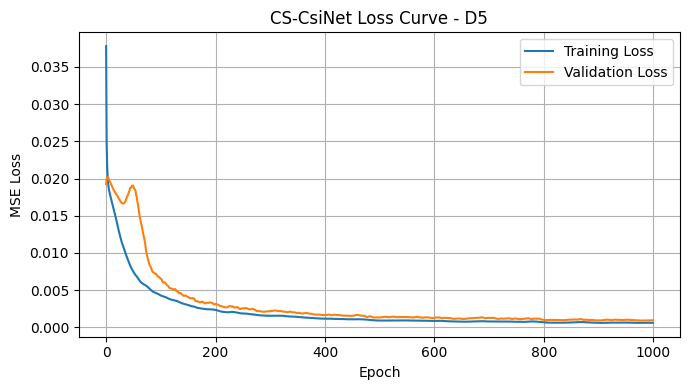

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
Average inference time per sample: 0.00717949 sec
Dataset: D5
Model: CS-CsiNet
Encoded dimension: 512
NMSE: -12.615239 dB
Correlation: 0.163860


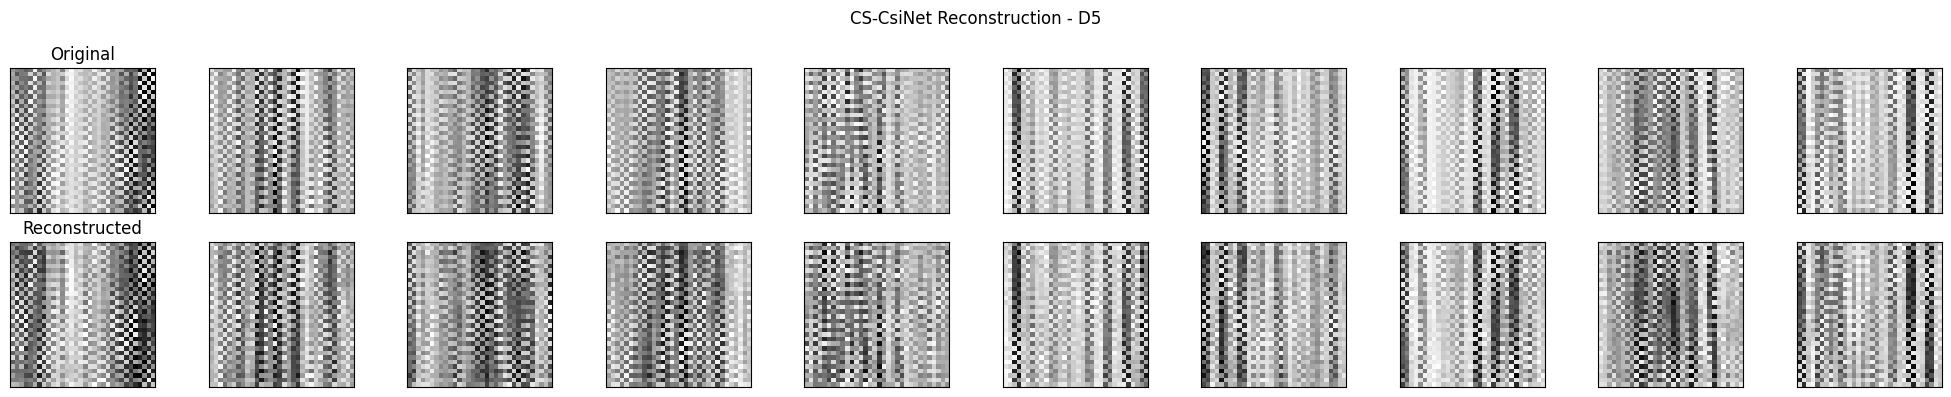

Saved files:
Loss curve: /content/drive/MyDrive/matdata/result_CS_D5/loss_curve_CS-CsiNet_D5_dim512_04_26_1502.png
Reconstruction figure: /content/drive/MyDrive/matdata/result_CS_D5/reconstruction_CS-CsiNet_D5_dim512_04_26_1502.png
Metrics: /content/drive/MyDrive/matdata/result_CS_D5/metrics_CS-CsiNet_D5_dim512_04_26_1502.txt
Model JSON: /content/drive/MyDrive/matdata/result_CS_D5/model_CS-CsiNet_D5_dim512_04_26_1502.json
Weights: /content/drive/MyDrive/matdata/result_CS_D5/model_CS-CsiNet_D5_dim512_04_26_1502.weights.h5
Projection matrix A: /content/drive/MyDrive/matdata/data_D5/A512.mat


In [ ]:
import os
import time
import math
import h5py
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Reshape,
    Conv2D, Add, LeakyReLU
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard, Callback

print("TensorFlow version:", tf.__version__)

# =========================================================
# 1. Basic Settings
# =========================================================
BASE_DIR = "/content/drive/MyDrive/matdata"

# 改這裡即可：D1, D2, D3, D4, D5, D6
DATASET_ID = "D5"

DATA_ROOT = os.path.join(BASE_DIR, f"data_{DATASET_ID}")
RESULT_ROOT = os.path.join(BASE_DIR, f"result_CS_{DATASET_ID}")
os.makedirs(RESULT_ROOT, exist_ok=True)

img_height = 32
img_width = 32
img_channels = 2
img_total = img_height * img_width * img_channels  # 2048

residual_num = 2
encoded_dim = 512

EPOCHS = 1000
BATCH_SIZE = 64
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("DATA_ROOT:", DATA_ROOT)
print("RESULT_ROOT:", RESULT_ROOT)

# =========================================================
# 2. MAT Loader: supports v7 and v7.3
# =========================================================
def load_mat_variable(path, key):
    """
    Load MATLAB .mat variable.
    Supports normal MAT files using scipy.io.loadmat
    and MATLAB v7.3 files using h5py.
    """
    try:
        mat = sio.loadmat(path)
        data = mat[key]
        return data
    except NotImplementedError:
        with h5py.File(path, "r") as f:
            data = np.array(f[key])

        # MATLAB v7.3 is often read with reversed dimensions.
        if key == "HT":
            if data.shape[0] == img_total:
                data = data.T

        if key == "HF_all":
            if len(data.shape) == 3:
                # MATLAB N x 32 x 125 may become 125 x 32 x N
                if data.shape[0] == 125 and data.shape[1] == 32:
                    data = np.transpose(data, (2, 1, 0))

            # complex compound dtype
            if data.dtype.fields is not None:
                fields = data.dtype.fields.keys()
                if "real" in fields and "imag" in fields:
                    data = data["real"] + 1j * data["imag"]
                elif "r" in fields and "i" in fields:
                    data = data["r"] + 1j * data["i"]
                else:
                    raise ValueError(f"Unknown complex fields in {key}: {fields}")

        if key == "A":
            # MATLAB A may be encoded_dim x 2048 or 2048 x encoded_dim depending on save/load
            pass

        return data

# =========================================================
# 3. Data Loading
# =========================================================
train_path = os.path.join(DATA_ROOT, "DATA_Htrainin.mat")
val_path   = os.path.join(DATA_ROOT, "DATA_Hvalin.mat")
test_path  = os.path.join(DATA_ROOT, "DATA_Htestin.mat")
hf_path    = os.path.join(DATA_ROOT, "DATA_HtestFin_all.mat")

for p in [train_path, val_path, test_path, hf_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")

x_train_flat = load_mat_variable(train_path, "HT")
x_val_flat   = load_mat_variable(val_path, "HT")
x_test_flat  = load_mat_variable(test_path, "HT")
X_test       = load_mat_variable(hf_path, "HF_all")

x_train_flat = x_train_flat.astype("float32")
x_val_flat   = x_val_flat.astype("float32")
x_test_flat  = x_test_flat.astype("float32")

print("x_train_flat:", x_train_flat.shape)
print("x_val_flat:", x_val_flat.shape)
print("x_test_flat:", x_test_flat.shape)
print("X_test:", X_test.shape)

# =========================================================
# 4. CS Random Projection Matrix A
# =========================================================
# 原始 CS-CsiNet 會讀 data/A512.mat。
# 如果沒有 A512.mat，這裡會自動產生固定 random projection matrix。
A_path = os.path.join(DATA_ROOT, f"A{encoded_dim}.mat")

if os.path.exists(A_path):
    print("Loading A from:", A_path)
    A = load_mat_variable(A_path, "A").astype("float32")
else:
    print(f"A{encoded_dim}.mat not found. Generating random projection matrix A.")
    rng = np.random.default_rng(SEED)

    # 原始程式 y = np.dot(x, A.T)，所以 A shape 要是 encoded_dim x 2048
    A = rng.uniform(low=-0.5, high=0.5, size=(encoded_dim, img_total)).astype("float32")

    # Optional normalization，避免 y 數值過大
    A = A / np.sqrt(encoded_dim).astype("float32") if hasattr(np.sqrt(encoded_dim), "astype") else A / np.sqrt(encoded_dim)

    sio.savemat(A_path, {"A": A})
    print("Saved generated A to:", A_path)

print("A shape:", A.shape)

# Ensure A shape is encoded_dim x 2048
if A.shape == (img_total, encoded_dim):
    A = A.T

if A.shape != (encoded_dim, img_total):
    raise ValueError(f"A shape should be ({encoded_dim}, {img_total}), but got {A.shape}")

# Compressed sensing measurements
# x: N x 2048, A.T: 2048 x 512 -> y: N x 512
y_train = np.dot(x_train_flat, A.T).astype("float32")
y_val   = np.dot(x_val_flat, A.T).astype("float32")
y_test  = np.dot(x_test_flat, A.T).astype("float32")

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

# Decoder target: N x 32 x 32 x 2
# Original HT: N x 2048 = N x (2 x 32 x 32)
x_train = x_train_flat.reshape(-1, 2, 32, 32)
x_val   = x_val_flat.reshape(-1, 2, 32, 32)
x_test  = x_test_flat.reshape(-1, 2, 32, 32)

# Colab / TensorFlow uses channels_last: N x 32 x 32 x 2
x_train = np.transpose(x_train, (0, 2, 3, 1))
x_val   = np.transpose(x_val, (0, 2, 3, 1))
x_test  = np.transpose(x_test, (0, 2, 3, 1))

print("x_train target:", x_train.shape)
print("x_val target:", x_val.shape)
print("x_test target:", x_test.shape)

# =========================================================
# 5. Build CS-CsiNet Decoder
# =========================================================
def add_common_layers(y):
    y = BatchNormalization()(y)
    y = LeakyReLU()(y)
    return y

def residual_block_decoded(y):
    shortcut = y

    y = Conv2D(8, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = add_common_layers(y)

    y = Conv2D(16, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = add_common_layers(y)

    y = Conv2D(2, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = BatchNormalization()(y)

    y = Add()([shortcut, y])
    y = LeakyReLU()(y)

    return y

def build_cs_csinet_decoder(encoded_dim=512, residual_num=2):
    encoded_input = Input(shape=(encoded_dim,))

    x = Dense(img_total, activation="linear")(encoded_input)
    x = Reshape((img_height, img_width, img_channels))(x)

    for _ in range(residual_num):
        x = residual_block_decoded(x)

    output = Conv2D(
        2,
        (3, 3),
        activation="sigmoid",
        padding="same",
        data_format="channels_last"
    )(x)

    model = Model(inputs=encoded_input, outputs=output)
    return model

decoder = build_cs_csinet_decoder(encoded_dim=encoded_dim, residual_num=residual_num)
decoder.compile(optimizer="adam", loss="mse")
decoder.summary()

# =========================================================
# 6. Callback
# =========================================================
class LossHistory(Callback):
    def on_train_begin(self, logs=None):
        self.losses_train = []
        self.losses_val = []

    def on_batch_end(self, batch, logs=None):
        self.losses_train.append(logs.get("loss"))

    def on_epoch_end(self, epoch, logs=None):
        self.losses_val.append(logs.get("val_loss"))

history = LossHistory()

file_tag = f"CS-CsiNet_{DATASET_ID}_dim{encoded_dim}" + time.strftime("_%m_%d_%H%M")
tb_path = os.path.join(RESULT_ROOT, f"TensorBoard_{file_tag}")

# =========================================================
# 7. Train Decoder
# =========================================================
train_start = time.time()

fit_history = decoder.fit(
    y_train,
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(y_val, x_val),
    callbacks=[
        history,
        TensorBoard(log_dir=tb_path)
    ],
    verbose=1
)

train_end = time.time()
print(f"Training time: {(train_end - train_start):.2f} sec")

# Save loss
train_loss_path = os.path.join(RESULT_ROOT, f"trainloss_{file_tag}.csv")
val_loss_path = os.path.join(RESULT_ROOT, f"valloss_{file_tag}.csv")

np.savetxt(train_loss_path, np.array(history.losses_train), delimiter=",")
np.savetxt(val_loss_path, np.array(history.losses_val), delimiter=",")

# Plot loss
plt.figure(figsize=(7, 4))
plt.plot(fit_history.history["loss"], label="Training Loss")
plt.plot(fit_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"CS-CsiNet Loss Curve - {DATASET_ID}")
plt.legend()
plt.grid(True)
plt.tight_layout()
loss_fig_path = os.path.join(RESULT_ROOT, f"loss_curve_{file_tag}.png")
plt.savefig(loss_fig_path, dpi=300)
plt.show()

# =========================================================
# 8. Test / Reconstruction
# =========================================================
t_start = time.time()
x_hat = decoder.predict(y_test, batch_size=BATCH_SIZE)
t_end = time.time()

print("Average inference time per sample: %.8f sec" % ((t_end - t_start) / x_test.shape[0]))

# =========================================================
# 9. NMSE and Correlation
# =========================================================
# x_test / x_hat shape: N x 32 x 32 x 2
x_test_real = x_test[:, :, :, 0].reshape(len(x_test), -1)
x_test_imag = x_test[:, :, :, 1].reshape(len(x_test), -1)
x_test_C = x_test_real - 0.5 + 1j * (x_test_imag - 0.5)

x_hat_real = x_hat[:, :, :, 0].reshape(len(x_hat), -1)
x_hat_imag = x_hat[:, :, :, 1].reshape(len(x_hat), -1)
x_hat_C = x_hat_real - 0.5 + 1j * (x_hat_imag - 0.5)

x_hat_F = x_hat_C.reshape(len(x_hat_C), img_height, img_width)
X_hat = np.fft.fft(
    np.concatenate(
        (x_hat_F, np.zeros((len(x_hat_C), img_height, 257 - img_width))),
        axis=2
    ),
    axis=2
)
X_hat = X_hat[:, :, 0:125]

X_test = np.asarray(X_test)

if X_test.shape[0] != len(x_test):
    print("Warning: X_test shape may be mismatched.")
    print("X_test:", X_test.shape)
    print("x_test:", x_test.shape)

# correlation
n1 = np.sqrt(np.sum(np.abs(X_test) ** 2, axis=1)).astype("float64")
n2 = np.sqrt(np.sum(np.abs(X_hat) ** 2, axis=1)).astype("float64")
aa = np.abs(np.sum(np.conj(X_test) * X_hat, axis=1))

rho = np.mean(aa / (n1 * n2 + 1e-12), axis=1)

# NMSE in angular-delay domain
power = np.sum(np.abs(x_test_C) ** 2, axis=1)
mse = np.sum(np.abs(x_test_C - x_hat_C) ** 2, axis=1)

nmse_linear = np.mean(mse / (power + 1e-12))
nmse_db = 10 * math.log10(nmse_linear)
corr = np.mean(rho)

print("====================================")
print(f"Dataset: {DATASET_ID}")
print(f"Model: CS-CsiNet")
print(f"Encoded dimension: {encoded_dim}")
print(f"NMSE: {nmse_db:.6f} dB")
print(f"Correlation: {corr:.6f}")
print("====================================")

# Save metrics
metrics_path = os.path.join(RESULT_ROOT, f"metrics_{file_tag}.txt")
with open(metrics_path, "w") as f:
    f.write(f"Dataset: {DATASET_ID}\n")
    f.write("Model: CS-CsiNet\n")
    f.write(f"Encoded dimension: {encoded_dim}\n")
    f.write(f"Epochs: {EPOCHS}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"NMSE_dB: {nmse_db:.6f}\n")
    f.write(f"Correlation: {corr:.6f}\n")

# Save decoded data and rho
decoded_path = os.path.join(RESULT_ROOT, f"decoded_{file_tag}.csv")
rho_path = os.path.join(RESULT_ROOT, f"rho_{file_tag}.csv")

x_hat_flat = x_hat.reshape(len(x_hat), -1)
np.savetxt(decoded_path, x_hat_flat, delimiter=",")
np.savetxt(rho_path, rho, delimiter=",")

# =========================================================
# 10. Visualization
# =========================================================
n = min(10, len(x_test))

plt.figure(figsize=(20, 4))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    x_test_mag = np.abs((x_test[i, :, :, 0] - 0.5) + 1j * (x_test[i, :, :, 1] - 0.5))
    plt.imshow(np.max(x_test_mag) - x_test_mag.T)
    plt.gray()
    ax.set_title("Original" if i == 0 else "")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.invert_yaxis()

    ax = plt.subplot(2, n, i + 1 + n)
    x_hat_mag = np.abs((x_hat[i, :, :, 0] - 0.5) + 1j * (x_hat[i, :, :, 1] - 0.5))
    plt.imshow(np.max(x_hat_mag) - x_hat_mag.T)
    plt.gray()
    ax.set_title("Reconstructed" if i == 0 else "")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.invert_yaxis()

plt.suptitle(f"CS-CsiNet Reconstruction - {DATASET_ID}")
plt.tight_layout()
recon_fig_path = os.path.join(RESULT_ROOT, f"reconstruction_{file_tag}.png")
plt.savefig(recon_fig_path, dpi=300)
plt.show()

# =========================================================
# 11. Save Decoder Model
# =========================================================
model_json = decoder.to_json()

json_path = os.path.join(RESULT_ROOT, f"model_{file_tag}.json")
weights_path = os.path.join(RESULT_ROOT, f"model_{file_tag}.weights.h5")

with open(json_path, "w") as json_file:
    json_file.write(model_json)

decoder.save_weights(weights_path)

print("Saved files:")
print("Loss curve:", loss_fig_path)
print("Reconstruction figure:", recon_fig_path)
print("Metrics:", metrics_path)
print("Model JSON:", json_path)
print("Weights:", weights_path)
print("Projection matrix A:", A_path)

#5.Mixed trained CsiNet

MIX_RESULT_ROOT: /content/drive/MyDrive/matdata/result_CsiNet_MIX
D1 train: (360, 2048) val: (45, 2048)
D2 train: (360, 2048) val: (45, 2048)
D3 train: (360, 2048) val: (45, 2048)
D4 train: (360, 2048) val: (45, 2048)
D5 train: (360, 2048) val: (45, 2048)
D6 train: (360, 2048) val: (45, 2048)
Mixed train: (2160, 2048)
Mixed val: (270, 2048)
Final mixed train: (2160, 32, 32, 2)
Final mixed val: (270, 32, 32, 2)


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 32, 32, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 32, 32, 2) │         38 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 2) │          8 │ conv2d_91[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_79      │ (None, 32, 32, 2) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 2048)      │          0 │ leaky_re_lu_79[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense       │ (None, 512)       │  1,049,088 │ flatten_7[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 2048)      │  1,050,624 │ encoder_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_12          │ (None, 32, 32, 2) │          0 │ dense_12[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 32, 32, 8) │        152 │ reshape_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 8) │         32 │ conv2d_92[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_80      │ (None, 32, 32, 8) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 32, 32,    │      1,168 │ leaky_re_lu_80[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_93[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_81      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 32, 32, 2) │        290 │ leaky_re_lu_81[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32, 2) │          8 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 32, 32, 2) │          0 │ reshape_12[0][0], │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_82      │ (None, 32, 32, 2) │          0 │ add_24[0][0]      │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,103,224 (8.02 MB)

 Trainable params: 2,103,116 (8.02 MB)

 Non-trainable params: 108 (432.00 B)

Epoch 1/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 231ms/step - loss: 0.0235 - val_loss: 0.0195
Epoch 2/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - loss: 0.0155 - val_loss: 0.0184
Epoch 3/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - loss: 0.0133 - val_loss: 0.0175
Epoch 4/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 219ms/step - loss: 0.0121 - val_loss: 0.0169
Epoch 5/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - loss: 0.0111 - val_loss: 0.0162
Epoch 6/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - loss: 0.0099 - val_loss: 0.0153
Epoch 7/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 219ms/step - loss: 0.0083 - val_loss: 0.0143
Epoch 8/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - loss: 0.0067 - val_loss: 0.0135
Epoch 9/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - loss: 0.0054 - val_loss: 0.0124
Epoch 10/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - loss: 0.0045 - val_loss: 0.0110
Epoch 11/1000
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step - loss: 0.0038 - val_loss: 0.0095
Epoch 12/1000
34/34 ━━━━━━

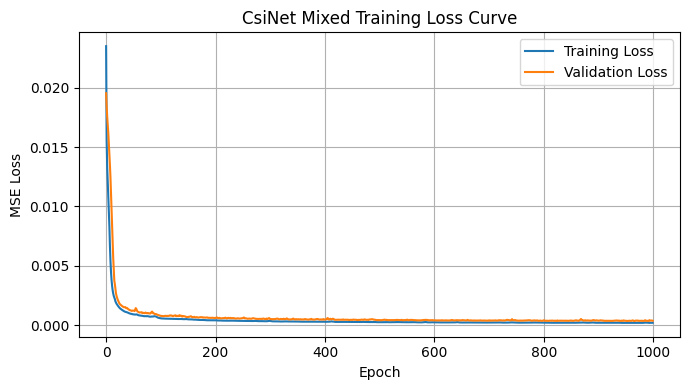

Saved mixed model: /content/drive/MyDrive/matdata/result_CsiNet_MIX/model_CsiNet_MIX_dim512_04_26_1546.weights.h5
Mixed-trained CsiNet tested on D1
NMSE: -19.199545 dB
Correlation: 0.150274
Inference time/sample: 0.01403612 sec
Mixed-trained CsiNet tested on D2
NMSE: -18.359496 dB
Correlation: 0.134155
Inference time/sample: 0.00345523 sec
Mixed-trained CsiNet tested on D3
NMSE: -19.421165 dB
Correlation: 0.127324
Inference time/sample: 0.00368096 sec
Mixed-trained CsiNet tested on D4
NMSE: -19.634966 dB
Correlation: 0.110657
Inference time/sample: 0.00510712 sec
Mixed-trained CsiNet tested on D5
NMSE: -15.362953 dB
Correlation: 0.160553
Inference time/sample: 0.00515776 sec
Mixed-trained CsiNet tested on D6
NMSE: -12.059943 dB
Correlation: 0.163679
Inference time/sample: 0.00474459 sec
Saved mixed test results: /content/drive/MyDrive/matdata/result_CsiNet_MIX/mixed_test_results_CsiNet_MIX_dim512_04_26_1546.csv

Comparison: Single-domain CsiNet vs Mixed-trained CsiNet
Dataset | Single 

In [ ]:
import os
import time
import math
import h5py
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Reshape, Conv2D, Add, LeakyReLU, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard, Callback

# =========================================================
# 1. Basic Settings
# =========================================================
BASE_DIR = "/content/drive/MyDrive/matdata"

DATASETS = ["D1", "D2", "D3", "D4", "D5", "D6"]

MIX_RESULT_ROOT = os.path.join(BASE_DIR, "result_CsiNet_MIX")
os.makedirs(MIX_RESULT_ROOT, exist_ok=True)

img_height = 32
img_width = 32
img_channels = 2
img_total = img_height * img_width * img_channels

residual_num = 2
encoded_dim = 512

EPOCHS = 1000
BATCH_SIZE = 64
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("MIX_RESULT_ROOT:", MIX_RESULT_ROOT)

# =========================================================
# 2. MAT Loader: supports v7 and v7.3
# =========================================================
def load_mat_variable(path, key):
    try:
        mat = sio.loadmat(path)
        return mat[key]
    except NotImplementedError:
        with h5py.File(path, "r") as f:
            data = np.array(f[key])

        if key == "HT":
            if data.shape[0] == img_total:
                data = data.T

        if key == "HF_all":
            if len(data.shape) == 3:
                if data.shape[0] == 125 and data.shape[1] == 32:
                    data = np.transpose(data, (2, 1, 0))

            if data.dtype.fields is not None:
                fields = data.dtype.fields.keys()
                if "real" in fields and "imag" in fields:
                    data = data["real"] + 1j * data["imag"]
                elif "r" in fields and "i" in fields:
                    data = data["r"] + 1j * data["i"]
                else:
                    raise ValueError(f"Unknown complex fields in {key}: {fields}")

        return data

# =========================================================
# 3. Load and Mix D1-D6 Training / Validation Data
# =========================================================
x_train_list = []
x_val_list = []

for ds in DATASETS:
    data_root = os.path.join(BASE_DIR, f"data_{ds}")

    train_path = os.path.join(data_root, "DATA_Htrainin.mat")
    val_path = os.path.join(data_root, "DATA_Hvalin.mat")

    x_train = load_mat_variable(train_path, "HT").astype("float32")
    x_val = load_mat_variable(val_path, "HT").astype("float32")

    print(ds, "train:", x_train.shape, "val:", x_val.shape)

    x_train_list.append(x_train)
    x_val_list.append(x_val)

x_train_mix = np.concatenate(x_train_list, axis=0)
x_val_mix = np.concatenate(x_val_list, axis=0)

print("Mixed train:", x_train_mix.shape)
print("Mixed val:", x_val_mix.shape)

# N x 2048 -> N x 2 x 32 x 32 -> N x 32 x 32 x 2
x_train_mix = x_train_mix.reshape(-1, 2, 32, 32)
x_val_mix = x_val_mix.reshape(-1, 2, 32, 32)

x_train_mix = np.transpose(x_train_mix, (0, 2, 3, 1))
x_val_mix = np.transpose(x_val_mix, (0, 2, 3, 1))

print("Final mixed train:", x_train_mix.shape)
print("Final mixed val:", x_val_mix.shape)

# =========================================================
# 4. Build CsiNet
# =========================================================
def add_common_layers(y):
    y = BatchNormalization()(y)
    y = LeakyReLU()(y)
    return y

def residual_block_decoded(y):
    shortcut = y

    y = Conv2D(8, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = add_common_layers(y)

    y = Conv2D(16, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = add_common_layers(y)

    y = Conv2D(2, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = BatchNormalization()(y)

    y = Add()([shortcut, y])
    y = LeakyReLU()(y)

    return y

def build_csinet(residual_num=2, encoded_dim=512):
    image_tensor = Input(shape=(img_height, img_width, img_channels))

    x = Conv2D(2, (3, 3), padding="same", data_format="channels_last")(image_tensor)
    x = add_common_layers(x)

    x = Flatten()(x)
    encoded = Dense(encoded_dim, activation="linear", name="encoder_dense")(x)

    x = Dense(img_total, activation="linear")(encoded)
    x = Reshape((img_height, img_width, img_channels))(x)

    for _ in range(residual_num):
        x = residual_block_decoded(x)

    output = Conv2D(
        2,
        (3, 3),
        activation="sigmoid",
        padding="same",
        data_format="channels_last"
    )(x)

    model = Model(inputs=image_tensor, outputs=output)
    return model

autoencoder = build_csinet(residual_num=residual_num, encoded_dim=encoded_dim)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# =========================================================
# 5. Train on Mixed Dataset
# =========================================================
file_tag = f"CsiNet_MIX_dim{encoded_dim}" + time.strftime("_%m_%d_%H%M")
tb_path = os.path.join(MIX_RESULT_ROOT, f"TensorBoard_{file_tag}")

train_start = time.time()

fit_history = autoencoder.fit(
    x_train_mix,
    x_train_mix,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_mix, x_val_mix),
    callbacks=[
        TensorBoard(log_dir=tb_path)
    ],
    verbose=1
)

train_end = time.time()
print(f"Mixed training time: {(train_end - train_start):.2f} sec")

# Save loss curve
plt.figure(figsize=(7, 4))
plt.plot(fit_history.history["loss"], label="Training Loss")
plt.plot(fit_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CsiNet Mixed Training Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = os.path.join(MIX_RESULT_ROOT, f"loss_curve_{file_tag}.png")
plt.savefig(loss_fig_path, dpi=300)
plt.show()

# Save mixed model
json_path = os.path.join(MIX_RESULT_ROOT, f"model_{file_tag}.json")
weights_path = os.path.join(MIX_RESULT_ROOT, f"model_{file_tag}.weights.h5")

with open(json_path, "w") as json_file:
    json_file.write(autoencoder.to_json())

autoencoder.save_weights(weights_path)

print("Saved mixed model:", weights_path)

# =========================================================
# 6. Evaluation Function
# =========================================================
def evaluate_on_dataset(model, dataset_id):
    data_root = os.path.join(BASE_DIR, f"data_{dataset_id}")

    test_path = os.path.join(data_root, "DATA_Htestin.mat")
    hf_path = os.path.join(data_root, "DATA_HtestFin_all.mat")

    x_test_flat = load_mat_variable(test_path, "HT").astype("float32")
    X_test = load_mat_variable(hf_path, "HF_all")

    x_test = x_test_flat.reshape(-1, 2, 32, 32)
    x_test = np.transpose(x_test, (0, 2, 3, 1))

    t_start = time.time()
    x_hat = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    t_end = time.time()

    # x_test / x_hat: N x 32 x 32 x 2
    x_test_real = x_test[:, :, :, 0].reshape(len(x_test), -1)
    x_test_imag = x_test[:, :, :, 1].reshape(len(x_test), -1)
    x_test_C = x_test_real - 0.5 + 1j * (x_test_imag - 0.5)

    x_hat_real = x_hat[:, :, :, 0].reshape(len(x_hat), -1)
    x_hat_imag = x_hat[:, :, :, 1].reshape(len(x_hat), -1)
    x_hat_C = x_hat_real - 0.5 + 1j * (x_hat_imag - 0.5)

    x_hat_F = x_hat_C.reshape(len(x_hat_C), img_height, img_width)

    X_hat = np.fft.fft(
        np.concatenate(
            (x_hat_F, np.zeros((len(x_hat_C), img_height, 257 - img_width))),
            axis=2
        ),
        axis=2
    )

    X_hat = X_hat[:, :, 0:125]

    X_test = np.asarray(X_test)

    n1 = np.sqrt(np.sum(np.abs(X_test) ** 2, axis=1)).astype("float64")
    n2 = np.sqrt(np.sum(np.abs(X_hat) ** 2, axis=1)).astype("float64")
    aa = np.abs(np.sum(np.conj(X_test) * X_hat, axis=1))

    rho = np.mean(aa / (n1 * n2 + 1e-12), axis=1)

    power = np.sum(np.abs(x_test_C) ** 2, axis=1)
    mse = np.sum(np.abs(x_test_C - x_hat_C) ** 2, axis=1)

    nmse_linear = np.mean(mse / (power + 1e-12))
    nmse_db = 10 * math.log10(nmse_linear)
    corr = np.mean(rho)
    infer_time = (t_end - t_start) / x_test.shape[0]

    return nmse_db, corr, infer_time, x_test, x_hat

# =========================================================
# 7. Test Mixed-Trained CsiNet on D1-D6
# =========================================================
mixed_results = []

for ds in DATASETS:
    nmse_db, corr, infer_time, x_test, x_hat = evaluate_on_dataset(autoencoder, ds)

    mixed_results.append([ds, nmse_db, corr, infer_time])

    print("====================================")
    print(f"Mixed-trained CsiNet tested on {ds}")
    print(f"NMSE: {nmse_db:.6f} dB")
    print(f"Correlation: {corr:.6f}")
    print(f"Inference time/sample: {infer_time:.8f} sec")
    print("====================================")

# Save mixed results
mixed_results = np.array(mixed_results, dtype=object)

result_csv_path = os.path.join(MIX_RESULT_ROOT, f"mixed_test_results_{file_tag}.csv")
with open(result_csv_path, "w") as f:
    f.write("Dataset,NMSE_dB,Correlation,InferenceTimePerSample\n")
    for row in mixed_results:
        f.write(f"{row[0]},{row[1]:.6f},{row[2]:.6f},{row[3]:.8f}\n")

print("Saved mixed test results:", result_csv_path)


#6.Mixed trained CS-CsiNet

In [ ]:
import os
import time
import math
import h5py
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Reshape, Conv2D, Add, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard

# =========================================================
# 1. Basic Settings
# =========================================================
BASE_DIR = "/content/drive/MyDrive/matdata"

DATASETS = ["D1", "D2", "D3", "D4", "D5", "D6"]

MIX_RESULT_ROOT = os.path.join(BASE_DIR, "result_CS_CsiNet_MIX")
os.makedirs(MIX_RESULT_ROOT, exist_ok=True)

img_height = 32
img_width = 32
img_channels = 2
img_total = img_height * img_width * img_channels  # 2048

residual_num = 2
encoded_dim = 512

EPOCHS = 1000
BATCH_SIZE = 64
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("MIX_RESULT_ROOT:", MIX_RESULT_ROOT)

# =========================================================
# 2. MAT Loader: supports v7 and v7.3
# =========================================================
def load_mat_variable(path, key):
    try:
        mat = sio.loadmat(path)
        return mat[key]
    except NotImplementedError:
        with h5py.File(path, "r") as f:
            data = np.array(f[key])

        if key == "HT":
            if data.shape[0] == img_total:
                data = data.T

        if key == "HF_all":
            if len(data.shape) == 3:
                if data.shape[0] == 125 and data.shape[1] == 32:
                    data = np.transpose(data, (2, 1, 0))

            if data.dtype.fields is not None:
                fields = data.dtype.fields.keys()
                if "real" in fields and "imag" in fields:
                    data = data["real"] + 1j * data["imag"]
                elif "r" in fields and "i" in fields:
                    data = data["r"] + 1j * data["i"]
                else:
                    raise ValueError(f"Unknown complex fields in {key}: {fields}")

        return data

# =========================================================
# 3. Load and Mix D1-D6 Training / Validation Data
# =========================================================
x_train_flat_list = []
x_val_flat_list = []

for ds in DATASETS:
    data_root = os.path.join(BASE_DIR, f"data_{ds}")

    train_path = os.path.join(data_root, "DATA_Htrainin.mat")
    val_path = os.path.join(data_root, "DATA_Hvalin.mat")

    x_train_flat = load_mat_variable(train_path, "HT").astype("float32")
    x_val_flat = load_mat_variable(val_path, "HT").astype("float32")

    print(ds, "train:", x_train_flat.shape, "val:", x_val_flat.shape)

    x_train_flat_list.append(x_train_flat)
    x_val_flat_list.append(x_val_flat)

x_train_flat_mix = np.concatenate(x_train_flat_list, axis=0)
x_val_flat_mix = np.concatenate(x_val_flat_list, axis=0)

print("Mixed train flat:", x_train_flat_mix.shape)
print("Mixed val flat:", x_val_flat_mix.shape)

# Target: N x 2048 -> N x 2 x 32 x 32 -> N x 32 x 32 x 2
x_train_mix = x_train_flat_mix.reshape(-1, 2, 32, 32)
x_val_mix = x_val_flat_mix.reshape(-1, 2, 32, 32)

x_train_mix = np.transpose(x_train_mix, (0, 2, 3, 1))
x_val_mix = np.transpose(x_val_mix, (0, 2, 3, 1))

print("Final mixed train target:", x_train_mix.shape)
print("Final mixed val target:", x_val_mix.shape)

# =========================================================
# 4. Fixed Random Projection Matrix A
# =========================================================
A_path = os.path.join(BASE_DIR, f"A{encoded_dim}_mixed.mat")

if os.path.exists(A_path):
    print("Loading A from:", A_path)
    A = load_mat_variable(A_path, "A").astype("float32")
else:
    print(f"A{encoded_dim}_mixed.mat not found. Generating fixed random projection matrix A.")
    rng = np.random.default_rng(SEED)

    # A shape: encoded_dim x 2048
    # y = x @ A.T
    A = rng.normal(
        loc=0.0,
        scale=1.0 / np.sqrt(encoded_dim),
        size=(encoded_dim, img_total)
    ).astype("float32")

    sio.savemat(A_path, {"A": A})
    print("Saved A to:", A_path)

if A.shape == (img_total, encoded_dim):
    A = A.T

if A.shape != (encoded_dim, img_total):
    raise ValueError(f"A shape should be ({encoded_dim}, {img_total}), but got {A.shape}")

print("A shape:", A.shape)

# CS measurement
y_train_mix = np.dot(x_train_flat_mix, A.T).astype("float32")
y_val_mix = np.dot(x_val_flat_mix, A.T).astype("float32")

print("y_train_mix:", y_train_mix.shape)
print("y_val_mix:", y_val_mix.shape)

# =========================================================
# 5. Build CS-CsiNet Decoder
# =========================================================
def add_common_layers(y):
    y = BatchNormalization()(y)
    y = LeakyReLU()(y)
    return y

def residual_block_decoded(y):
    shortcut = y

    y = Conv2D(8, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = add_common_layers(y)

    y = Conv2D(16, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = add_common_layers(y)

    y = Conv2D(2, kernel_size=(3, 3), padding="same", data_format="channels_last")(y)
    y = BatchNormalization()(y)

    y = Add()([shortcut, y])
    y = LeakyReLU()(y)

    return y

def build_cs_csinet_decoder(encoded_dim=512, residual_num=2):
    encoded_input = Input(shape=(encoded_dim,))

    x = Dense(img_total, activation="linear")(encoded_input)
    x = Reshape((img_height, img_width, img_channels))(x)

    for _ in range(residual_num):
        x = residual_block_decoded(x)

    output = Conv2D(
        2,
        (3, 3),
        activation="sigmoid",
        padding="same",
        data_format="channels_last"
    )(x)

    model = Model(inputs=encoded_input, outputs=output)
    return model

decoder = build_cs_csinet_decoder(encoded_dim=encoded_dim, residual_num=residual_num)
decoder.compile(optimizer="adam", loss="mse")
decoder.summary()

# =========================================================
# 6. Train Mixed CS-CsiNet
# =========================================================
file_tag = f"CS_CsiNet_MIX_dim{encoded_dim}" + time.strftime("_%m_%d_%H%M")
tb_path = os.path.join(MIX_RESULT_ROOT, f"TensorBoard_{file_tag}")

train_start = time.time()

fit_history = decoder.fit(
    y_train_mix,
    x_train_mix,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(y_val_mix, x_val_mix),
    callbacks=[
        TensorBoard(log_dir=tb_path)
    ],
    verbose=1
)

train_end = time.time()
print(f"Mixed CS-CsiNet training time: {(train_end - train_start):.2f} sec")

# Save loss curve
plt.figure(figsize=(7, 4))
plt.plot(fit_history.history["loss"], label="Training Loss")
plt.plot(fit_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CS-CsiNet Mixed Training Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = os.path.join(MIX_RESULT_ROOT, f"loss_curve_{file_tag}.png")
plt.savefig(loss_fig_path, dpi=300)
plt.show()

# Save mixed CS-CsiNet model
json_path = os.path.join(MIX_RESULT_ROOT, f"model_{file_tag}.json")
weights_path = os.path.join(MIX_RESULT_ROOT, f"model_{file_tag}.weights.h5")

with open(json_path, "w") as json_file:
    json_file.write(decoder.to_json())

decoder.save_weights(weights_path)

print("Saved mixed CS-CsiNet model:", weights_path)

# =========================================================
# 7. Evaluation Function
# =========================================================
def evaluate_cs_on_dataset(model, dataset_id, A):
    data_root = os.path.join(BASE_DIR, f"data_{dataset_id}")

    test_path = os.path.join(data_root, "DATA_Htestin.mat")
    hf_path = os.path.join(data_root, "DATA_HtestFin_all.mat")

    x_test_flat = load_mat_variable(test_path, "HT").astype("float32")
    X_test = load_mat_variable(hf_path, "HF_all")

    # CS measurement for test data
    y_test = np.dot(x_test_flat, A.T).astype("float32")

    # Target shape
    x_test = x_test_flat.reshape(-1, 2, 32, 32)
    x_test = np.transpose(x_test, (0, 2, 3, 1))

    t_start = time.time()
    x_hat = model.predict(y_test, batch_size=BATCH_SIZE, verbose=0)
    t_end = time.time()

    # x_test / x_hat: N x 32 x 32 x 2
    x_test_real = x_test[:, :, :, 0].reshape(len(x_test), -1)
    x_test_imag = x_test[:, :, :, 1].reshape(len(x_test), -1)
    x_test_C = x_test_real - 0.5 + 1j * (x_test_imag - 0.5)

    x_hat_real = x_hat[:, :, :, 0].reshape(len(x_hat), -1)
    x_hat_imag = x_hat[:, :, :, 1].reshape(len(x_hat), -1)
    x_hat_C = x_hat_real - 0.5 + 1j * (x_hat_imag - 0.5)

    # Frequency-domain reconstruction for correlation
    x_hat_F = x_hat_C.reshape(len(x_hat_C), img_height, img_width)

    X_hat = np.fft.fft(
        np.concatenate(
            (x_hat_F, np.zeros((len(x_hat_C), img_height, 257 - img_width))),
            axis=2
        ),
        axis=2
    )

    X_hat = X_hat[:, :, 0:125]
    X_test = np.asarray(X_test)

    n1 = np.sqrt(np.sum(np.abs(X_test) ** 2, axis=1)).astype("float64")
    n2 = np.sqrt(np.sum(np.abs(X_hat) ** 2, axis=1)).astype("float64")
    aa = np.abs(np.sum(np.conj(X_test) * X_hat, axis=1))

    rho = np.mean(aa / (n1 * n2 + 1e-12), axis=1)

    power = np.sum(np.abs(x_test_C) ** 2, axis=1)
    mse = np.sum(np.abs(x_test_C - x_hat_C) ** 2, axis=1)

    nmse_linear = np.mean(mse / (power + 1e-12))
    nmse_db = 10 * math.log10(nmse_linear)
    corr = np.mean(rho)
    infer_time = (t_end - t_start) / x_test.shape[0]

    return nmse_db, corr, infer_time, x_test, x_hat

# =========================================================
# 8. Test Mixed-Trained CS-CsiNet on D1-D6
# =========================================================
mixed_results = []

for ds in DATASETS:
    nmse_db, corr, infer_time, x_test, x_hat = evaluate_cs_on_dataset(decoder, ds, A)

    mixed_results.append([ds, nmse_db, corr, infer_time])

    print("====================================")
    print(f"Mixed-trained CS-CsiNet tested on {ds}")
    print(f"NMSE: {nmse_db:.6f} dB")
    print(f"Correlation: {corr:.6f}")
    print(f"Inference time/sample: {infer_time:.8f} sec")
    print("====================================")

# Save mixed results
mixed_results = np.array(mixed_results, dtype=object)

result_csv_path = os.path.join(MIX_RESULT_ROOT, f"mixed_CS_test_results_{file_tag}.csv")
with open(result_csv_path, "w") as f:
    f.write("Dataset,NMSE_dB,Correlation,InferenceTimePerSample\n")
    for row in mixed_results:
        f.write(f"{row[0]},{row[1]:.6f},{row[2]:.6f},{row[3]:.8f}\n")

print("Saved mixed CS-CsiNet test results:", result_csv_path)

# =========================================================
# 9. Compare with Single-domain CS-CsiNet Results
# =========================================================
single_results = {
    "D1": {"CS_NMSE": -15.3053, "CS_Corr": 0.1502},
    "D2": {"CS_NMSE": -14.8795, "CS_Corr": 0.1366},
    "D3": {"CS_NMSE": -13.1215, "CS_Corr": 0.1296},
    "D4": {"CS_NMSE": -16.5968, "CS_Corr": 0.1269},
    "D5": {"CS_NMSE": -12.6152, "CS_Corr": 0.1638},
    "D6": {"CS_NMSE": -9.9710,  "CS_Corr": 0.1604},
}

print("\nComparison: Single-domain CS-CsiNet vs Mixed-trained CS-CsiNet")
print("Dataset | Single NMSE | Mixed NMSE | Single Corr | Mixed Corr")
print("-" * 75)

for row in mixed_results:
    ds = row[0]
    mixed_nmse = float(row[1])
    mixed_corr = float(row[2])

    single_nmse = single_results[ds]["CS_NMSE"]
    single_corr = single_results[ds]["CS_Corr"]

    print(
        f"{ds:>3} | "
        f"{single_nmse:>10.4f} | "
        f"{mixed_nmse:>10.4f} | "
        f"{single_corr:>10.4f} | "
        f"{mixed_corr:>10.4f}"
    )